In [1]:
pip install fireducks pandas matplotlib numpy duckdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 MB 16.8 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0


In [2]:
FIREDUCKS_FLAGS = "--benchmark-mode"

In [3]:
import pandas as pd
import numpy as np

# Generate data
n_rows = 10_000_000

df = pd.DataFrame({
    'transaction_id': np.arange(1, n_rows + 1),
    'customer_id': np.random.randint(1, 500_000, n_rows),
    'product_category': np.random.choice(['electronics', 'clothing', 'books', 'home', 'sports'], n_rows),
    'price': np.round(np.random.uniform(5, 2000, n_rows), 2),
    'quantity': np.random.randint(1, 5, n_rows),
    'purchase_date': pd.date_range(start='2022-01-01', periods=n_rows, freq='s')
})

# Save to CSV
df.to_csv('ecommerce_10m.csv', index=False)

print("✅ E-commerce dataset with 10 Million rows generated successfully!")


✅ E-commerce dataset with 10 Million rows generated successfully!


In [4]:
import pandas as pd
import fireducks.pandas as fd
import time

# --- Pandas ---
start = time.time()
df_pandas = pd.read_csv('ecommerce_10m.csv')
print("📦 Pandas read time:", round(time.time() - start, 4), "seconds")

# --- FireDucks ---
start = time.time()
df_fd = fd.read_csv('ecommerce_10m.csv')
print("🚀 FireDucks read time:", round(time.time() - start, 4), "seconds")


📦 Pandas read time: 11.9015 seconds
🚀 FireDucks read time: 0.2443 seconds


In [5]:
# --- Pandas ---
df_pandas = pd.read_csv('ecommerce_10m.csv')
start = time.time()
result_pandas = df_pandas.groupby('product_category')['price'].mean()
print("📦 Pandas groupby time:", round(time.time() - start, 4), "seconds")

# --- FireDucks ---
df_fd = fd.read_csv('ecommerce_10m.csv')
start = time.time()
result_fd = df_fd.groupby('product_category')['price'].mean()
print("🚀 FireDucks groupby time:", round(time.time() - start, 4), "seconds")


📦 Pandas groupby time: 1.1785 seconds
🚀 FireDucks groupby time: 0.002 seconds


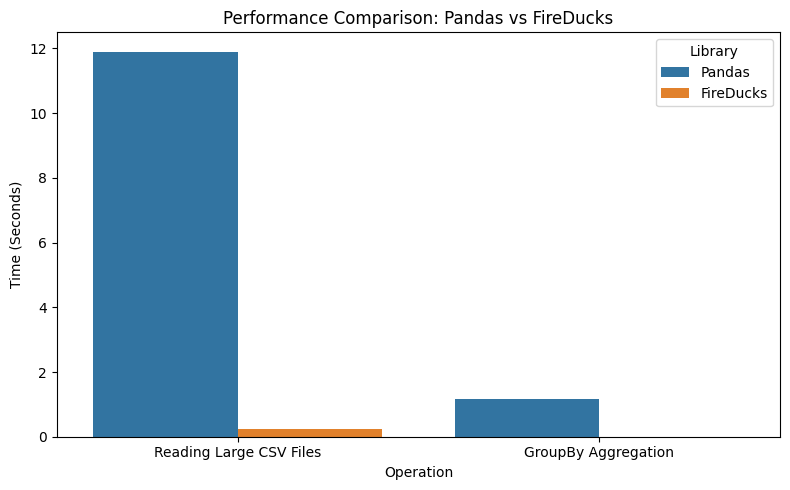

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
data = {
    "Operation": ["Reading Large CSV Files", "GroupBy Aggregation"],
    "Pandas": [11.9015, 1.1785],
    "FireDucks": [0.2443, 0.002]
}

df = pd.DataFrame(data)

df_melted = df.melt(id_vars="Operation", var_name="Library", value_name="Time (Seconds)")

plt.figure(figsize=(8, 5))
sns.barplot(x="Operation", y="Time (Seconds)", hue="Library", data=df_melted)
plt.title("Performance Comparison: Pandas vs FireDucks")
plt.ylabel("Time (Seconds)")
plt.xlabel("Operation")
plt.legend(title="Library")
plt.tight_layout()
plt.show()
